# XBeach Declarative Workflow

This notebook demonstrates the **declarative approach** to setting up an XBeach model
using rompy-xbeach. The entire configuration is defined in a YAML file, which is then
loaded and executed.

## Why Declarative?

The declarative approach offers several advantages:

- **Reproducibility** - Configuration is version-controlled and shareable
- **Separation of concerns** - Configuration is separate from execution logic
- **Automation** - Easy to integrate with workflows and batch processing
- **Validation** - YAML is validated against the Pydantic schema

For the **procedural approach** with step-by-step Python code, see the companion notebook.

In [1]:
from pathlib import Path
from datetime import timedelta
import shutil
import yaml
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

---
# The YAML Configuration

The configuration file defines all aspects of the model:
- **run_id** and **output_dir** - Run identification and output location
- **period** - Simulation time range
- **config** - Complete XBeach configuration (grid, bathy, forcing, physics, output)

In [2]:
# View the YAML configuration
yaml_file = Path("example-declarative.yml")
print(yaml_file.read_text())

# XBeach Declarative Configuration Example
# 
# This YAML file defines a complete XBeach model configuration.
# It can be loaded directly by rompy to generate the model workspace.

run_id: declarative_example
output_dir: example-declarative-output
period:
  start: 2023-01-01T00:00
  end: 2023-01-01T12:00
  interval: 1h

config:
  model_type: xbeach
  
  # ===================
  # Grid Definition
  # ===================
  grid:
    model_type: regular
    ori:
      x: 115.594239
      y: -32.641104
      crs: EPSG:4326
    alfa: 347.0
    dx: 10.0
    dy: 15.0
    nx: 230
    ny: 220
    crs: EPSG:28350
  
  # ===================
  # Bathymetry
  # ===================
  bathy:
    model_type: xbeach_bathy
    source:
      model_type: geotiff
      filename: /source/csiro/rompy-xbeach/tests/data/bathy.tif
    posdwn: false
    interpolator:
      model_type: scipy_regular_grid
      kwargs:
        method: linear
        fill_value: null
    extension:
      model_type: linear
      dep

## YAML Structure Overview

```yaml
run_id: my_run              # Unique run identifier
output_dir: ./output        # Output directory
period:
  start: 2023-01-01T00:00   # Simulation start
  end: 2023-01-01T12:00     # Simulation end
  interval: 1h              # Time interval for forcing

config:
  model_type: xbeach        # Model type (required)
  grid: {...}               # Grid definition
  bathy: {...}              # Bathymetry configuration
  input:                    # Forcing data
    wave: {...}             # Wave boundary
    wind: {...}             # Wind forcing
    tide: {...}             # Tide forcing
  flow_boundary: {...}      # Flow boundary conditions
  tide_boundary: {...}      # Tide boundary settings
  output: {...}             # Output configuration
```

---
# Load and Instantiate the Model

In [3]:
from rompy.model import ModelRun

# Load YAML configuration
with open(yaml_file) as f:
    conf = yaml.safe_load(f)

# Create ModelRun from configuration
modelrun = ModelRun(**conf)

print(f"Run ID: {modelrun.run_id}")
print(f"Output directory: {modelrun.output_dir}")
print(f"Period: {modelrun.period.start} to {modelrun.period.end}")

Run ID: declarative_example
Output directory: example-declarative-output
Period: 2023-01-01 00:00:00 to 2023-01-01 12:00:00


---
# Quality Control (Optional)

With the declarative approach, you can generate the workspace directly without
intermediate inspection. However, for illustration, we can inspect the grid and
bathymetry before generating the full workspace.

## Inspect Grid

Text(0.5, 1.0, 'Model Grid')

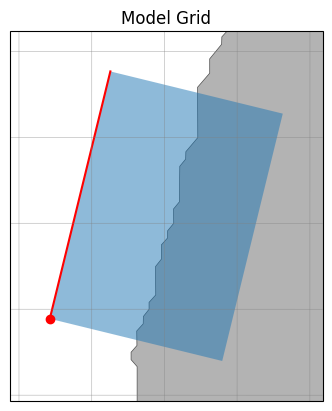

In [4]:
ax = modelrun.config.grid.plot(scale="f")
ax.set_title("Model Grid")

## Inspect Bathymetry

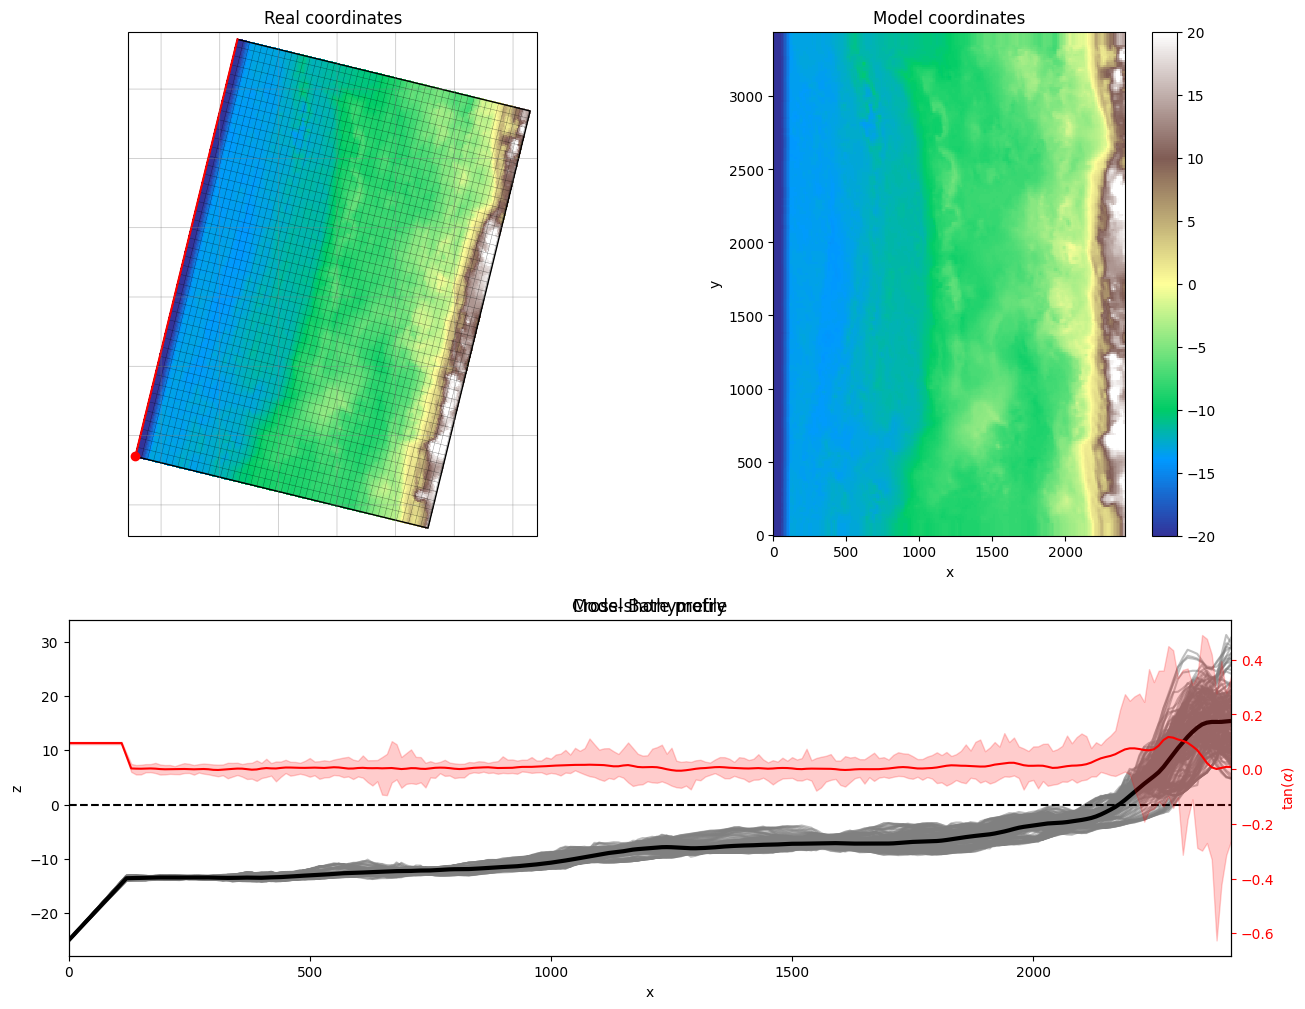

In [5]:
# Generate bathymetry to a temporary directory for inspection
tmpdir = Path("tmp_bathy_check")
tmpdir.mkdir(exist_ok=True)

xfile, yfile, depfile, grid_extended = modelrun.config.bathy.get(
    destdir=tmpdir,
    grid=modelrun.config.grid,
)

# Load and plot
dset = xr.Dataset.xbeach.from_xbeach(depfile, grid_extended)
dset.xbeach.plot_model_bathy(grid_extended, posdwn=False)
plt.title("Model Bathymetry")

# Cleanup
shutil.rmtree(tmpdir)

---
# Generate the Workspace

The `ModelRun` object generates all XBeach input files when called.

In [6]:
# Clean output directory if it exists
output_dir = Path(modelrun.output_dir)
if output_dir.exists():
    shutil.rmtree(output_dir)

# Generate the workspace
rundir = modelrun()

2026-01-11 12:51:27 [INFO] rompy.model         : ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
2026-01-11 12:51:27 [INFO] rompy.model         : ┃                      MODEL RUN CONFIGURATION                       ┃
2026-01-11 12:51:27 [INFO] rompy.model         : ┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛
2026-01-11 12:51:27 [INFO] rompy.model         :             Run ID : declarative_example
2026-01-11 12:51:27 [INFO] rompy.model         :         Model Type : Config
2026-01-11 12:51:27 [INFO] rompy.model         :         Start Time : 2023-01-01T00:00:00
2026-01-11 12:51:27 [INFO] rompy.model         :           End Time : 2023-01-01T12:00:00
2026-01-11 12:51:27 [INFO] rompy.model         :           Duration : 12 hours
2026-01-11 12:51:27 [INFO] rompy.model         :      Time Interval : 1:00:00
2026-01-11 12:51:27 [INFO] rompy.model         :   Output Directory : example-declarative-output
2026-01-11 12:51:27 [INFO] rompy.model 

---
# Inspect Generated Files

In [7]:
# List generated files
modeldir = Path(modelrun.output_dir) / modelrun.run_id
print("Generated files:")
for f in sorted(modeldir.glob("*")):
    print(f"  {f.name}")

Generated files:
  bathy.txt
  params.txt
  swan-20230101T000000.txt
  tide-20230101T000000-20230101T120000.txt
  wind-20230101T000000-20230101T120000.txt
  xdata.txt
  ydata.txt


In [8]:
# View params.txt
params_file = modeldir / "params.txt"
print(params_file.read_text()[:2000])

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%%% XBeach parameter settings input file
%%%
%%% Date: 2026-01-10 23:51:27.428827+00:00
%%% User: rguedes-XPS-13-9350
%%% Template: /source/csiro/rompy-xbeach/src/rompy_xbeach/templates/base
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

tstop = 43200.0
tunits = seconds since 2023-01-01 00:00:00
wbctype = swan
bcfile = swan-20230101T000000.txt
windfile = wind-20230101T000000-20230101T120000.txt
zs0file = tide-20230101T000000-20230101T120000.txt
tideloc = 1
tidelen = 13
front = abs_2d
back = abs_2d
left = neumann
right = neumann
zs0 = 0.0
paulrevere = land
posdwn = -1
nx = 241
ny = 229
dx = 10.0
dy = 15.0
xori = 368011.2066131959
yori = 6387580.505638544
alfa = 347.0
projection = +proj=utm +zone=50 +south +ellps=GRS80 +units=m +no_defs +type=crs
depfile = bathy.txt
outputformat = netcdf
ncfilename = xboutput.nc
tstart = 0.0
tintm = 3600.0



## Inspect Forcing Files

In [9]:
def read_forcing(filepath, cols):
    """Read XBeach forcing file."""
    df = pd.read_csv(filepath, header=None, sep=r"\s+", names=cols)
    if "tsec" in cols:
        df["time"] = [modelrun.period.start + timedelta(seconds=s) for s in df.tsec]
        df.set_index("time", inplace=True)
    return df

### Wind Forcing

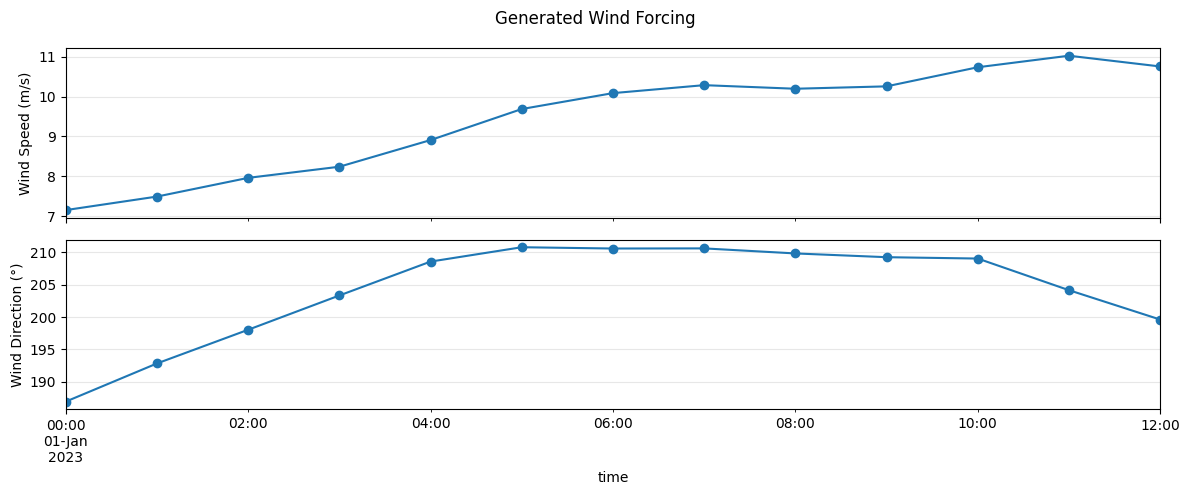

In [10]:
windfile = list(modeldir.glob("wind-*.txt"))
if windfile:
    df_wind = read_forcing(windfile[0], ["tsec", "wspd", "wdir"])
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
    df_wind.wspd.plot(ax=ax1, marker="o")
    ax1.set_ylabel("Wind Speed (m/s)")
    ax1.grid(True, alpha=0.3)
    
    df_wind.wdir.plot(ax=ax2, marker="o")
    ax2.set_ylabel("Wind Direction (°)")
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle("Generated Wind Forcing")
    plt.tight_layout()

### Tide Forcing

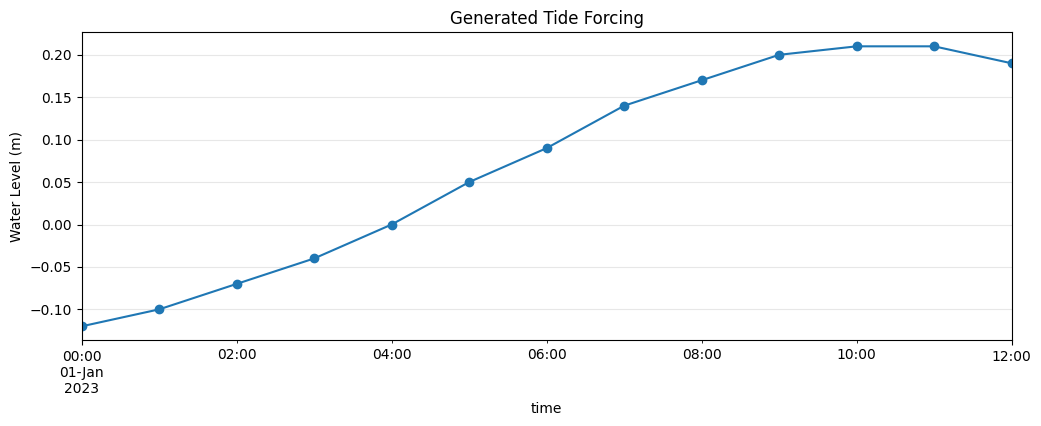

In [11]:
tidefile = list(modeldir.glob("tide-*.txt"))
if tidefile:
    df_tide = read_forcing(tidefile[0], ["tsec", "zs"])
    
    fig, ax = plt.subplots(figsize=(12, 4))
    df_tide.zs.plot(ax=ax, marker="o")
    ax.set_ylabel("Water Level (m)")
    ax.set_title("Generated Tide Forcing")
    ax.grid(True, alpha=0.3)

### Wave Boundary

In [12]:
bcfile = list(modeldir.glob("swan-*.txt"))[0]
if bcfile:
    print(f"Wave boundary file: {bcfile.name}")
    print(bcfile.read_text()[:500])

Wave boundary file: swan-20230101T000000.txt
SWAN   1                                Swan standard spectral file
$   Created by wavespectra
$   
LONLAT                                  locations in spherical coordinates
     1                                  number of locations
  115.598402  -32.626715
AFREQ                                   absolute frequencies in Hz
    31                                  number of frequencies
    0.03700
    0.04070
    0.04477
    0.04925
    0.05417
    0.05959
    0.06555
    0.07210
    0.07931
   


<xarray.Dataset> Size: 6kB
Dimensions:  (time: 1, lat: 1, lon: 1, freq: 31, dir: 24)
Coordinates:
  * time     (time) datetime64[ns] 8B 2026-01-11T12:51:00
  * lat      (lat) float64 8B -32.63
  * lon      (lon) float64 8B 115.6
  * freq     (freq) float64 248B 0.037 0.0407 0.04477 ... 0.5336 0.5869 0.6456
  * dir      (dir) float64 192B 0.0 15.0 30.0 45.0 ... 300.0 315.0 330.0 345.0
Data variables:
    efth     (time, lat, lon, freq, dir) float64 6kB 0.0 0.0 0.0 ... 0.0 0.0 0.0

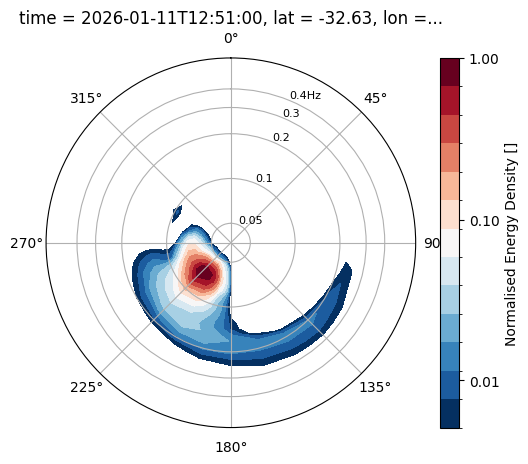

In [13]:
from wavespectra import read_swan

ds = read_swan(bcfile)
display(ds)
ds.squeeze().spec.plot()

---
# Summary

This notebook demonstrated the **declarative workflow** for XBeach:

1. **Define configuration in YAML** - All settings in one file
2. **Load with ModelRun** - Validate and instantiate
3. **Quality control** - Inspect grid and bathymetry
4. **Generate workspace** - Create all XBeach input files

## Advantages of Declarative Approach

| Aspect | Benefit |
|--------|---------|
| Version control | Track configuration changes in git |
| Reproducibility | Same YAML = same model setup |
| Automation | Easy to use in scripts and pipelines |
| Sharing | Share configurations with collaborators |
| Validation | Pydantic validates all fields |

## Next Steps

- See **Example Procedural** for step-by-step Python approach
- See component tutorials for detailed parameter options
- See data interface tutorials for forcing options

## Running XBeach

```bash
cd example-declarative-output/declarative_example
xbeach params.txt
```